In [1]:
import pandas as pd
import matplotlib.pyplot as plt

customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")

In [2]:
revenue_df = (
    orders
    .merge(
        customers,
        on="customer_id",
        how="left"
    )
    .merge(
        items[
            [
                "order_id",
                "product_id",
                "price"
            ]
        ],
        on="order_id",
        how="left"
    )
)

In [3]:
total_revenue = revenue_df["price"].sum()

print(
    f"Total Revenue: {total_revenue:,.2f}"
)

Total Revenue: 13,591,643.70


In [4]:
state_revenue = (
    revenue_df
    .groupby("customer_state")
    ["price"]
    .sum()
    .sort_values(
        ascending=False
    )
)

state_revenue.head(10)

customer_state
SP    5202955.05
RJ    1824092.67
MG    1585308.03
RS     750304.02
PR     683083.76
SC     520553.34
BA     511349.99
DF     302603.94
GO     294591.95
ES     275037.31
Name: price, dtype: float64

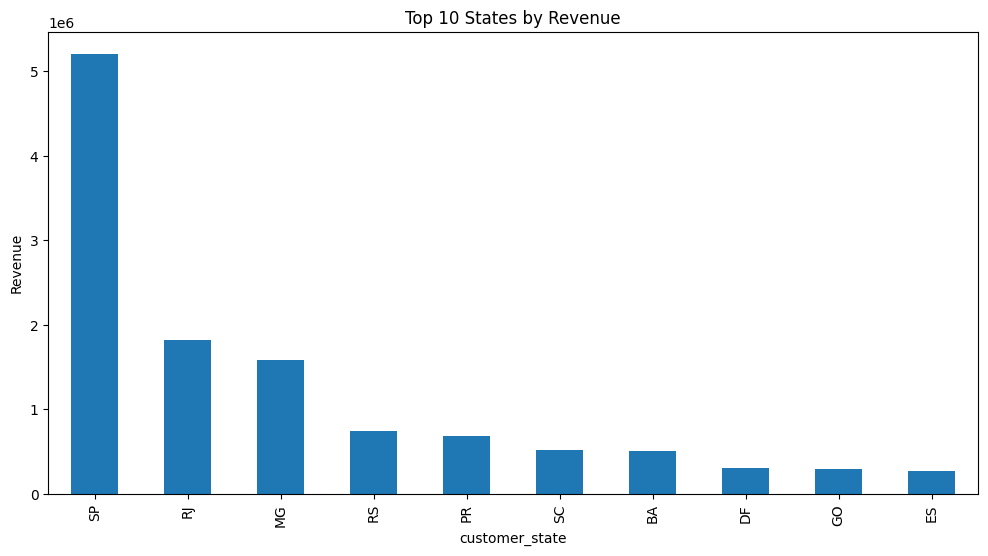

In [5]:
plt.figure(figsize=(12,6))

state_revenue.head(10).plot(
    kind="bar"
)

plt.title(
    "Top 10 States by Revenue"
)

plt.ylabel("Revenue")

plt.show()

In [6]:
top5_share = (
    state_revenue.head(5).sum()
    /
    state_revenue.sum()
) * 100

print(
    f"Top 5 States Contribution: {top5_share:.2f}%"
)

Top 5 States Contribution: 73.91%


In [7]:
state_revenue.head(10)

customer_state
SP    5202955.05
RJ    1824092.67
MG    1585308.03
RS     750304.02
PR     683083.76
SC     520553.34
BA     511349.99
DF     302603.94
GO     294591.95
ES     275037.31
Name: price, dtype: float64

In [8]:
top5_share

np.float64(73.91117477571899)

## Revenue by State Findings

1. São Paulo (SP) is the largest revenue-generating state, contributing over 5.2 million in revenue.
2. Rio de Janeiro (RJ) and Minas Gerais (MG) are the second and third largest contributors.
3. The top 5 states account for approximately 73.9% of total platform revenue.
4. Revenue is highly concentrated in a small number of geographic regions.
5. Operational issues in high-revenue states could have a significant business impact.

In [9]:
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")

orders = orders[
    orders["order_status"] == "delivered"
].copy()

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

orders["is_late"] = (
    orders["order_delivered_customer_date"]
    >
    orders["order_estimated_delivery_date"]
).astype(int)

sla_state = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

state_late = (
    sla_state
    .groupby("customer_state")
    .agg(
        total_orders=("order_id", "count"),
        late_orders=("is_late", "sum")
    )
)

state_late["late_rate"] = (
    state_late["late_orders"]
    /
    state_late["total_orders"]
) * 100

state_late = state_late.reset_index()

In [10]:
state_revenue_reset = state_revenue.reset_index()

state_analysis = (
    state_revenue_reset
    .merge(
        state_late[
            [
                "customer_state",
                "late_rate"
            ]
        ],
        on="customer_state",
        how="left"
    )
)

state_analysis.head()

,customer_state,price,late_rate
0,SP,5202955.05,5.893682
1,RJ,1824092.67,13.473684
2,MG,1585308.03,5.610358
3,RS,750304.02,7.146866
4,PR,683083.76,4.996953


In [11]:
state_analysis

,customer_state,price,late_rate
0,SP,5202955.05,5.893682
1,RJ,1824092.67,13.473684
2,MG,1585308.03,5.610358
3,RS,750304.02,7.146866
4,PR,683083.76,4.996953
5,SC,520553.34,9.757473
6,BA,511349.99,14.035627
7,DF,302603.94,7.067308
8,GO,294591.95,8.175779
9,ES,275037.31,12.230576


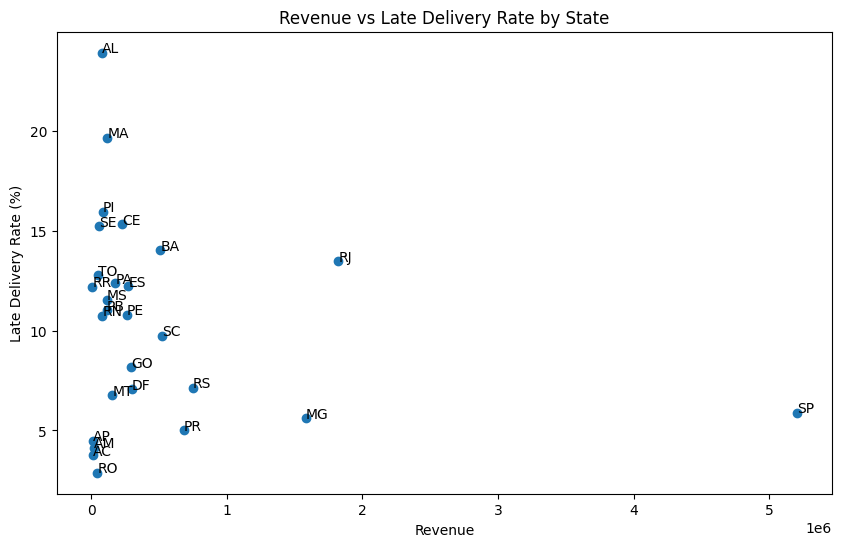

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    state_analysis["price"],
    state_analysis["late_rate"]
)

for _, row in state_analysis.iterrows():
    plt.annotate(
        row["customer_state"],
        (
            row["price"],
            row["late_rate"]
        )
    )

plt.xlabel("Revenue")
plt.ylabel("Late Delivery Rate (%)")
plt.title("Revenue vs Late Delivery Rate by State")

plt.show()

## Revenue vs SLA Findings

1. São Paulo (SP) is the largest revenue-generating state and maintains a relatively low late delivery rate.
2. Rio de Janeiro (RJ) generates significant revenue but exhibits a high SLA breach rate, making it a critical operational risk area.
3. Minas Gerais (MG) demonstrates both strong revenue generation and efficient delivery performance.
4. States such as AL and MA have the highest delay rates but contribute comparatively less revenue.
5. Operational improvement efforts should prioritize high-revenue states with elevated delay rates, particularly RJ.

In [13]:
category_translation = pd.read_csv(
    "../data/raw/product_category_name_translation.csv"
)

In [14]:
category_revenue = (
    items
    .merge(
        products[
            [
                "product_id",
                "product_category_name"
            ]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        category_translation,
        on="product_category_name",
        how="left"
    )
)

In [15]:
category_revenue.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,garden_tools


In [16]:
top_categories = (
    category_revenue
    .groupby(
        "product_category_name_english"
    )["price"]
    .sum()
    .sort_values(
        ascending=False
    )
)

top_categories.head(10)

product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: price, dtype: float64

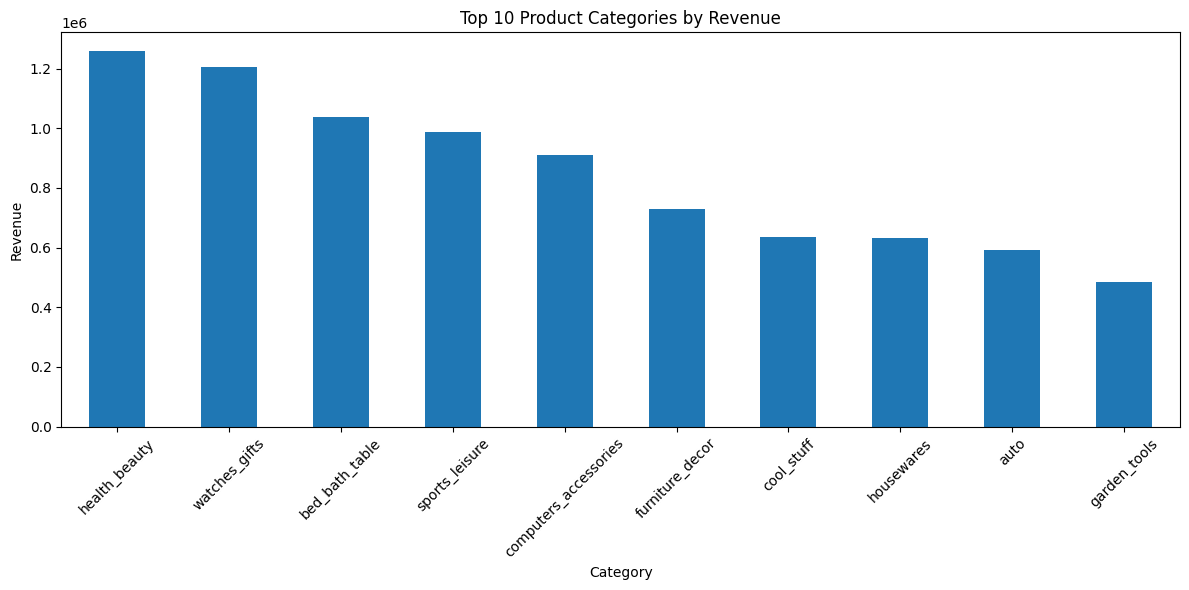

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

top_categories.head(10).plot(
    kind="bar"
)

plt.title(
    "Top 10 Product Categories by Revenue"
)

plt.ylabel("Revenue")

plt.xlabel("Category")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [18]:
top10_share = (
    top_categories.head(10).sum()
    /
    top_categories.sum()
) * 100

print(
    f"Top 10 Categories Revenue Share: {top10_share:.2f}%"
)

Top 10 Categories Revenue Share: 63.22%


In [19]:
print(
    top_categories.head(1)
)

product_category_name_english
health_beauty    1258681.34
Name: price, dtype: float64


In [20]:
top_categories.head(10)

product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: price, dtype: float64

## Product Category Findings

1. Health & Beauty is the highest revenue-generating product category.
2. Watches & Gifts and Bed Bath Table are also major revenue contributors.
3. Revenue is concentrated in a small number of product categories.
4. The top five categories collectively contribute a significant share of total platform revenue.
5. Category-focused inventory and marketing strategies could maximize revenue growth.